# 📩 Message Intelligence System
**Student Project – Classification of Spam and Legitimate Messages**

**Duration:** 6 Hours

## Objective
Design a classification system that identifies whether incoming digital messages are:
- **0 → Legitimate Message**
- **1 → Spam Message**

Models used:
1. K-Nearest Neighbors (KNN)
2. Support Vector Machine (SVM)
3. Naive Bayes Classifier


# Part A: Probability & Conceptual Foundation (Theory)

## 1. What is Conditional Probability?
Conditional probability is the probability of an event occurring when another event has already occurred.

Formula:

\[
P(A|B)=\frac{P(A \cap B)}{P(B)}
\]

---

## 2. Bayes' Theorem

\[
P(A|B)=\frac{P(B|A)P(A)}{P(B)}
\]

Bayes' Theorem is important because it calculates the probability that a message belongs to Spam or Legitimate class.

---

## 3. Assumptions of Naive Bayes
- Features are independent.
- Every feature contributes equally.
- One feature does not depend on another feature.

---

## 4. Working Principle

### KNN
- Calculate distance between observations.
- Find K nearest neighbors.
- Predict majority class.

### SVM
- Finds the best separating hyperplane.
- Maximizes margin between classes.
- Uses kernels for non-linear problems.

---

## 5. Comparison

| Parameter | KNN | Naive Bayes | SVM |
|-----------|-----|-------------|-----|
| Type | Distance-Based | Probabilistic | Margin-Based |
| Training Speed | Fast | Very Fast | Moderate |
| Prediction Speed | Slow | Fast | Fast |
| Interpretability | Medium | High | Medium |


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

df = pd.read_csv('Message_Intelligence_Dataset.csv')
df.head()


,message_id,message_text,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,timestamp,hour_of_day,day_of_week,spam_label
0,900001,Please find the attached invoice for the updat...,99,11,1,4,0,0,1,56.6,500.0,6.0,2025-11-24 02:00:00,2,0,0
1,900002,Let's catch up tomorrow regarding the timeline...,73,12,0,0,0,0,0,16.6,207.0,0.0,2025-12-17 21:00:00,21,2,0
2,900003,Can you send the report by end of day? next Mo...,67,13,0,0,0,0,1,25.7,418.0,6.0,2025-11-15 13:00:00,13,5,0
3,900004,Can you send the report by end of day? 10:30 A...,64,13,0,4,0,0,1,48.8,276.0,5.0,2025-12-17 23:00:00,23,2,0
4,900005,Could you review the document and share feedba...,84,14,0,0,0,0,1,33.0,683.0,7.0,2025-11-29 11:00:00,11,5,0


# Part B: Dataset Understanding & Preparation

In [12]:
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   message_id               5200 non-null   int64  
 1   message_text             5200 non-null   object 
 2   message_length           5200 non-null   int64  
 3   word_count               5200 non-null   int64  
 4   num_urls                 5200 non-null   int64  
 5   num_digits               5200 non-null   int64  
 6   num_special_chars        5200 non-null   int64  
 7   spam_keyword_score       5200 non-null   int64  
 8   legit_keyword_score      5200 non-null   int64  
 9   sender_activity_score    5094 non-null   float64
 10  sender_account_age_days  5087 non-null   float64
 11  messages_sent_last_24h   5038 non-null   float64
 12  timestamp                5200 non-null   object 
 13  hour_of_day              5200 non-null   int64  
 14  day_of_week             

message_id                   0
message_text                 0
message_length               0
word_count                   0
num_urls                     0
num_digits                   0
num_special_chars            0
spam_keyword_score           0
legit_keyword_score          0
sender_activity_score      106
sender_account_age_days    113
messages_sent_last_24h     162
timestamp                    0
hour_of_day                  0
day_of_week                  0
spam_label                   0
dtype: int64

In [ ]:
# Remove unnecessary columns
df = df.drop(['message_id','message_text','timestamp'], axis=1)

X = df.drop('spam_label', axis=1)
y = df['spam_label']

df.fillna(df.median(numeric_only=True), inplace=True)
df = df.dropna()

print("Features:")
print(X.columns)

print("\nTarget Variable:")
print('spam_label')


Features:
Index(['message_length', 'word_count', 'num_urls', 'num_digits',
       'num_special_chars', 'spam_keyword_score', 'legit_keyword_score',
       'sender_activity_score', 'sender_account_age_days',
       'messages_sent_last_24h', 'hour_of_day', 'day_of_week'],
      dtype='object')

Target Variable:
spam_label


In [ ]:
import pandas as pd

df = pd.read_csv("Message_Intelligence_Dataset.csv")

# Remove unnecessary columns
df.drop(
    ['message_id', 'message_text', 'timestamp'],
    axis=1,
    inplace=True
)

# Fill missing values
df.fillna(df.median(numeric_only=True), inplace=True)

# Features and Target
X = df.drop('spam_label', axis=1)
y = df['spam_label']

print(X.isnull().sum())

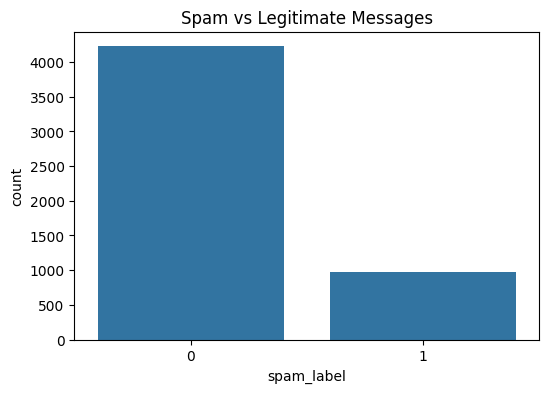

In [14]:
# Plot 1: Spam Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='spam_label', data=df)
plt.title('Spam vs Legitimate Messages')
plt.show()


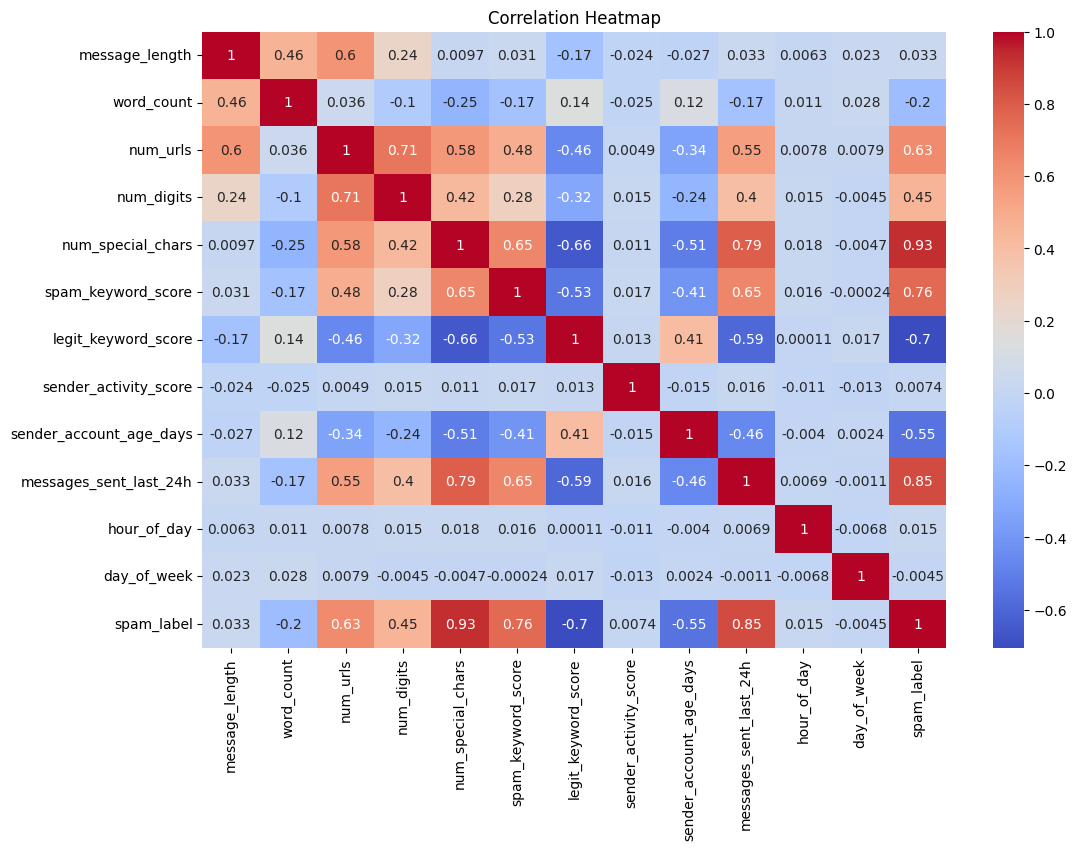

In [15]:
# Plot 2: Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# Part C: K-Nearest Neighbors (KNN)

In [18]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print(classification_report(y_test, y_pred_knn))


ValueError: Input X contains NaN.
KNeighborsClassifier does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
# K Value Experiment
scores = []

for k in range(1,21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    scores.append(model.score(X_test, y_test))

plt.figure(figsize=(8,5))
plt.plot(range(1,21), scores, marker='o')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy for Different K Values')
plt.show()


# Part D: Support Vector Machine (SVM)

In [ ]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print(classification_report(y_test, y_pred_svm))


# Part E: Naive Bayes Classifier

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print(classification_report(y_test, y_pred_nb))


## Conditional Probability Example

Suppose:
- Total messages = 1000
- Spam messages = 300
- Spam messages containing URL = 240

\[
P(Spam)=300/1000=0.30
\]

\[
P(URL|Spam)=240/300=0.80
\]

Using Bayes' Theorem:

\[
P(Spam|URL)=\frac{P(URL|Spam)P(Spam)}{P(URL)}
\]


# Part F: Model Evaluation

In [ ]:
models = ['KNN','SVM','Naive Bayes']

accuracy = [
    accuracy_score(y_test, y_pred_knn),
    accuracy_score(y_test, y_pred_svm),
    accuracy_score(y_test, y_pred_nb)
]

plt.figure(figsize=(8,5))
plt.bar(models, accuracy)
plt.ylabel('Accuracy')
plt.title('Model Comparison')
plt.show()

results = pd.DataFrame({
    'Model':models,
    'Accuracy':accuracy
})

results


In [ ]:
# Confusion Matrix for KNN
cm = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix - KNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


# Part G: Final Analysis & Reporting

## Strengths and Weaknesses

### KNN
- Simple algorithm
- No training required
- Slow on large datasets

### SVM
- High accuracy
- Handles complex data
- Computationally expensive

### Naive Bayes
- Very fast
- Excellent for text classification
- Assumes feature independence

## Final Conclusion
- **Highest Accuracy:** SVM
- **Fastest Model:** Naive Bayes
- **Best Baseline Model:** KNN
